# Jobsheet 3 - Teknik Regrresi Gambar

## Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

### setup dan generator dataset

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1)     # radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r)      # center x
  cy = np.random.randint(r, img_size - r)      # center y
  cv2.circle(img, (cx, cy), r, (255,), -1)    # lingkaran penuh terisi
  img = (img / 255.0).astype(np.float32)
  # 3 channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

### tebak apa - tampilkan contoh gambar tanpa label

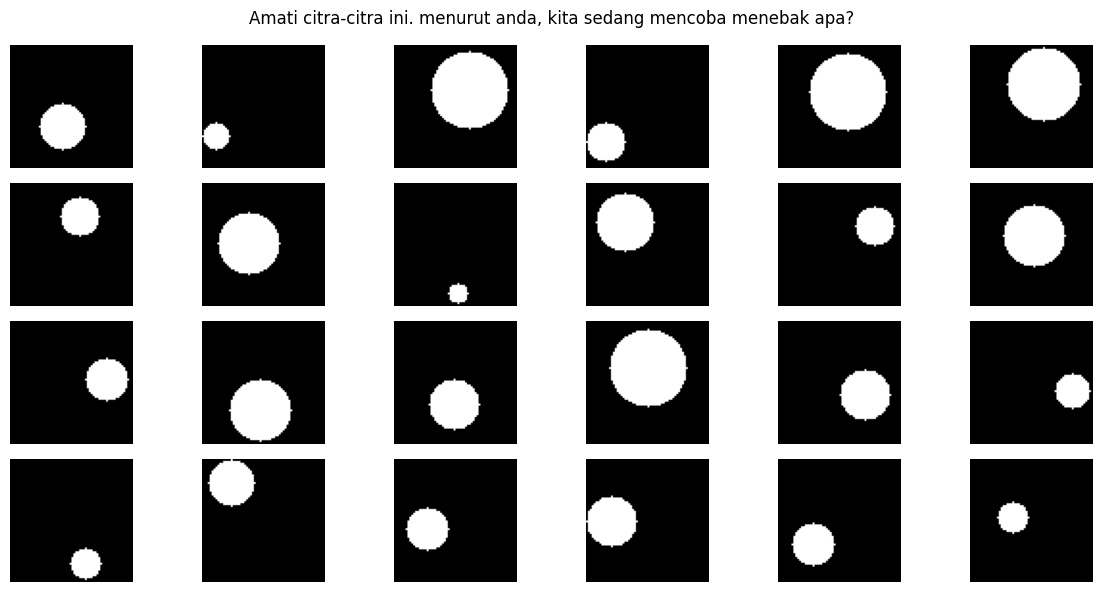

In [8]:
# buat 24 contoh visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# grid tanpa label
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.axis('off')

plt.suptitle("Amati citra-citra ini. menurut anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

### Buka Jawaban — Target yang Ingin Diprediksi

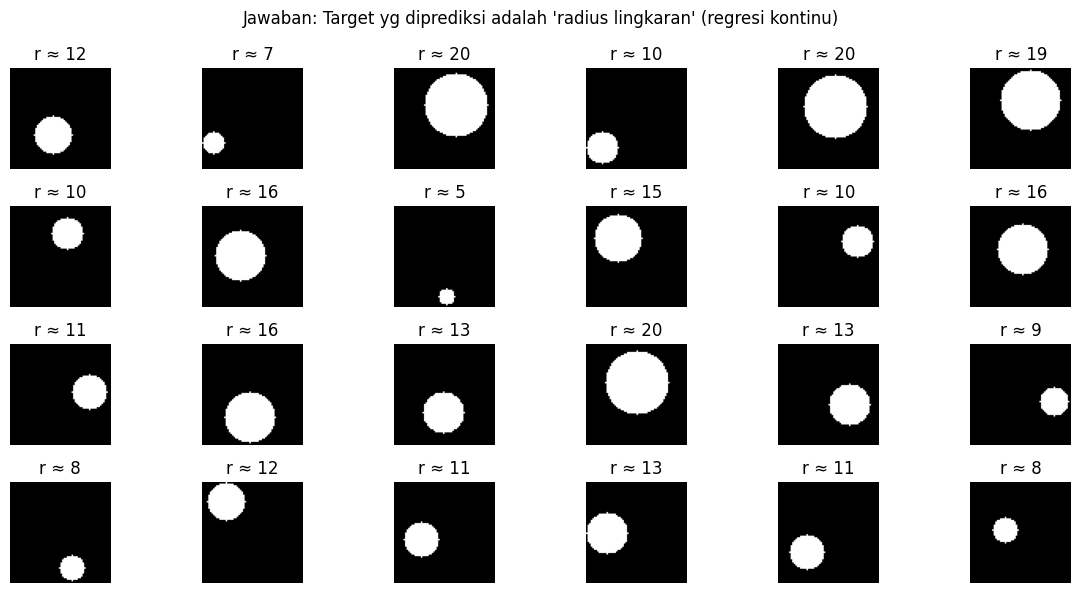

In [10]:
# tampilkan kembali, sekarang tampilkan radius (label) dijudul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.title(f"r ≈ {int(rads[i])}")
  plt.axis('off')

plt.suptitle("Jawaban: Target yg diprediksi adalah 'radius lingkaran' (regresi kontinu)")
plt.tight_layout()
plt.show()